# Exercise 2 — Non-Linearity in Higher Dimensions

Dois datasets 5D com a mesma dimensionalidade e estruturas diferentes: gaussianas
deslocadas (Dataset I) e cascas concêntricas (Dataset II).

Semente fixa: `rng = np.random.default_rng(42)`, o mesmo `rng` em todo o notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)  # semente fixa exigida pelo enunciado
N = 500

## A — Dataset I: shifted Gaussians

In [2]:
mu_A = np.zeros(5)
mu_B = np.full(5, 1.5)

Sigma_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0],
])
Sigma_B = np.array([
    [ 1.5, -0.7, 0.2, 0.0, 0.0],
    [-0.7,  1.5, 0.4, 0.0, 0.0],
    [ 0.2,  0.4, 1.5, 0.6, 0.0],
    [ 0.0,  0.0, 0.6, 1.5, 0.3],
    [ 0.0,  0.0, 0.0, 0.3, 1.5],
])

X_A = rng.multivariate_normal(mu_A, Sigma_A, N)
X_B = rng.multivariate_normal(mu_B, Sigma_B, N)
print("Dataset I:", X_A.shape, X_B.shape)

Dataset I: (500, 5) (500, 5)


As classes têm dispersões diferentes: $\Sigma_B$ tem variâncias maiores (1.5 vs. 1.0)
e correlação **negativa** entre as duas primeiras features (−0.7), enquanto em
$\Sigma_A$ ela é positiva (+0.8).

## B — Dataset II: concentric shells

Direções uniformes na esfera unitária de $\mathbb{R}^5$
($v \sim \mathcal{N}(0, I_5)$, $u = v/\lVert v \rVert$) e raio gaussiano por classe;
cada ponto é $x = \rho \cdot u$. O parâmetro `0.4` do enunciado foi tratado como
**desvio-padrão** do raio.

In [3]:
def shells(rng, radius_mean, radius_sd, n=N):
    """Casca esférica em 5D: direção uniforme na esfera unitária × raio gaussiano."""
    v = rng.normal(size=(n, 5))
    u = v / np.linalg.norm(v, axis=1, keepdims=True)  # direção na esfera unitária
    rho = rng.normal(radius_mean, radius_sd, n)       # raio
    return rho[:, None] * u

X_C = shells(rng, 2.0, 0.4)  # núcleo
X_D = shells(rng, 5.0, 0.4)  # casca
print("Dataset II:", X_C.shape, X_D.shape)

Dataset II: (500, 5) (500, 5)


## C — Visualize and compare

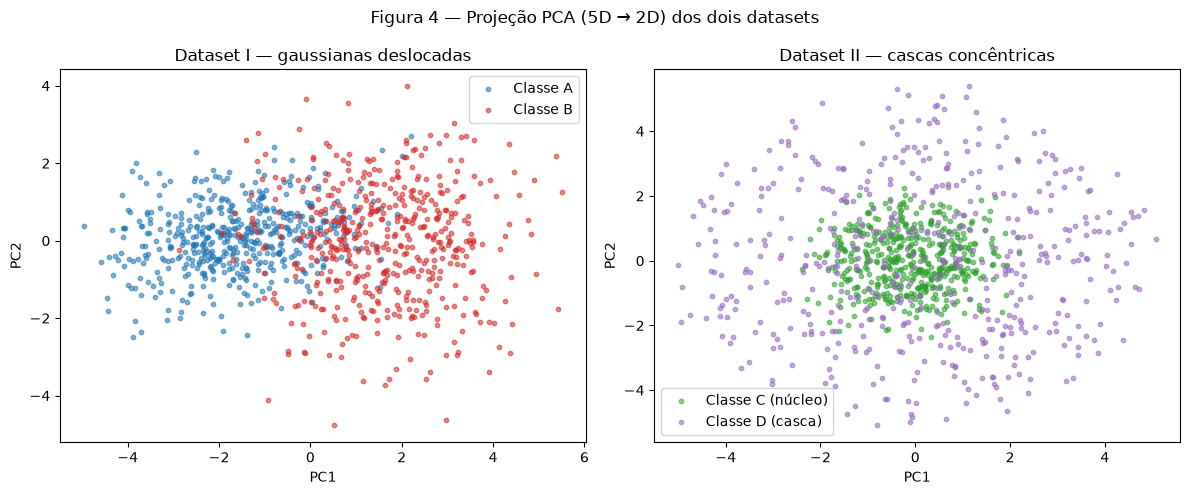

Variância explicada Dataset I : PC1 = 0.5004, PC2 = 0.1593, soma = 0.6597
Variância explicada Dataset II: PC1 = 0.2159, PC2 = 0.2132, soma = 0.4291


In [4]:
# PCA por dataset (ajustado sobre as duas classes juntas)
pca_1 = PCA(n_components=2).fit(np.vstack([X_A, X_B]))
pca_2 = PCA(n_components=2).fit(np.vstack([X_C, X_D]))
P_A, P_B = pca_1.transform(X_A), pca_1.transform(X_B)
P_C, P_D = pca_2.transform(X_C), pca_2.transform(X_D)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(P_A[:, 0], P_A[:, 1], s=10, alpha=0.55, color="tab:blue",  label="Classe A")
axes[0].scatter(P_B[:, 0], P_B[:, 1], s=10, alpha=0.55, color="tab:red",   label="Classe B")
axes[0].set_title("Dataset I — gaussianas deslocadas")
axes[1].scatter(P_C[:, 0], P_C[:, 1], s=10, alpha=0.55, color="tab:green", label="Classe C (núcleo)")
axes[1].scatter(P_D[:, 0], P_D[:, 1], s=10, alpha=0.55, color="tab:purple", label="Classe D (casca)")
axes[1].set_title("Dataset II — cascas concêntricas")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
fig.suptitle("Figura 4 — Projeção PCA (5D → 2D) dos dois datasets")
plt.tight_layout()
plt.show()

evr_1 = pca_1.explained_variance_ratio_
evr_2 = pca_2.explained_variance_ratio_
print(f"Variância explicada Dataset I : PC1 = {evr_1[0]:.4f}, PC2 = {evr_1[1]:.4f}, "
      f"soma = {evr_1.sum():.4f}")
print(f"Variância explicada Dataset II: PC1 = {evr_2[0]:.4f}, PC2 = {evr_2[1]:.4f}, "
      f"soma = {evr_2.sum():.4f}")

Distância entre centros (5D) — Dataset I : 3.2282
Distância entre centros (5D) — Dataset II: 0.2662


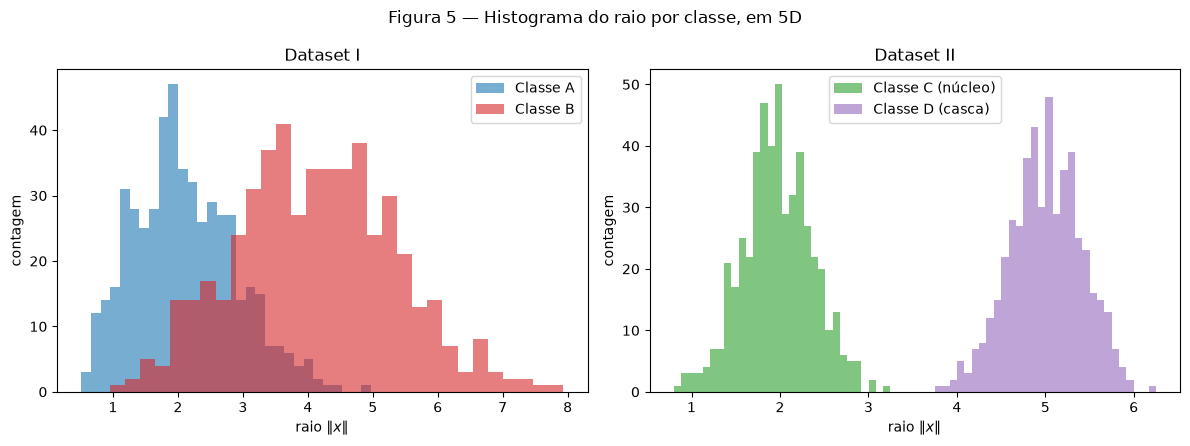

Raios Dataset II — C: 1.97 ± 0.40 (máx 3.25) | D: 5.00 ± 0.41 (mín 3.75)


In [5]:
# Medidas geométricas em 5D
dist_1 = np.linalg.norm(X_A.mean(axis=0) - X_B.mean(axis=0))
dist_2 = np.linalg.norm(X_C.mean(axis=0) - X_D.mean(axis=0))
print(f"Distância entre centros (5D) — Dataset I : {dist_1:.4f}")
print(f"Distância entre centros (5D) — Dataset II: {dist_2:.4f}")

r_A = np.linalg.norm(X_A, axis=1)
r_B = np.linalg.norm(X_B, axis=1)
r_C = np.linalg.norm(X_C, axis=1)
r_D = np.linalg.norm(X_D, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(r_A, bins=30, alpha=0.6, color="tab:blue",  label="Classe A")
axes[0].hist(r_B, bins=30, alpha=0.6, color="tab:red",   label="Classe B")
axes[0].set_title("Dataset I")
axes[1].hist(r_C, bins=30, alpha=0.6, color="tab:green", label="Classe C (núcleo)")
axes[1].hist(r_D, bins=30, alpha=0.6, color="tab:purple", label="Classe D (casca)")
axes[1].set_title("Dataset II")
for ax in axes:
    ax.set_xlabel("raio $\\|x\\|$")
    ax.set_ylabel("contagem")
    ax.legend()
fig.suptitle("Figura 5 — Histograma do raio por classe, em 5D")
plt.tight_layout()
plt.show()

print(f"Raios Dataset II — C: {r_C.mean():.2f} ± {r_C.std():.2f} "
      f"(máx {r_C.max():.2f}) | D: {r_D.mean():.2f} ± {r_D.std():.2f} "
      f"(mín {r_D.min():.2f})")

**Números.** Variância explicada por PC1+PC2: **0.6597** no Dataset I
(PC1 = 0.5004, PC2 = 0.1593) contra **0.4291** no Dataset II
(PC1 = 0.2159, PC2 = 0.2132). Distância entre centros em 5D: **3.2282** no
Dataset I (valor teórico $1.5\sqrt{5} = 3.354$) contra **0.2662** no Dataset II.

A projeção 2D preserva melhor a informação de classe no **Dataset I**: o
deslocamento entre as médias cria uma direção privilegiada de variância, que o PCA
captura em PC1 — na Figura 4 as classes aparecem como dois blocos com sobreposição
parcial. No Dataset II a variância é praticamente igual em todas as direções
(PC1 ≈ PC2 ≈ 21.5%, como esperado para dados isotrópicos em 5D), e a projeção mostra
apenas um disco com as classes misturadas — enquanto a Figura 5 mostra que, em 5D,
os raios das duas classes são perfeitamente separados
(C: 1.97 ± 0.40, máx 3.25; D: 5.00 ± 0.41, mín 3.75).

## D — Analysis

**1. Centros coincidentes × raios separados.** A distância entre os centros do
Dataset II é 0.2662 (≈ 0), mas os histogramas de raio não se tocam. Um hiperplano
separa por *posição ao longo de uma direção* — e as duas classes ocupam as mesmas
posições em todas as direções, diferindo apenas na *distância à origem*. Nenhum
hiperplano, portanto, separa as classes: a informação discriminante é radial, não
direcional.

**2. Por que mais dados não resolvem.** Por simetria esférica, a projeção de cada
classe sobre **qualquer** direção $w$ é simétrica em torno de zero, e as projeções
das duas classes se sobrepõem fortemente. Coletar mais dados apenas estima melhor
essas mesmas distribuições sobrepostas — o erro de qualquer classificador linear
permanece alto. A limitação é estrutural (da família de fronteiras), não estatística
(da amostra).

**3. Projeção PCA misturada prova inseparabilidade?** Não. O PCA é uma transformação
**linear**, e o Dataset II é o contraexemplo: a projeção 2D é um borrão
(PC1+PC2 = 42.9%), mas as classes são perfeitamente separáveis por uma função
não-linear simples das entradas:

$$ f(x) = \lVert x \rVert^2 = \sum_{i=1}^{5} x_i^2, \qquad
\text{classe C se } f(x) < 3.5^2 = 12.25 $$

In [6]:
# Verificação da função proposta (regra fixa, nada é treinado)
f_C = (X_C ** 2).sum(axis=1)
f_D = (X_D ** 2).sum(axis=1)
acc = ((f_C < 12.25).sum() + (f_D >= 12.25).sum()) / (2 * N)
print(f"Regra f(x) = Σx² < 12.25 → acurácia na amostra: {acc:.4f}")

Regra f(x) = Σx² < 12.25 → acurácia na amostra: 1.0000


A regra $\sum_i x_i^2 < 12.25$ classifica corretamente **100%** das 1000 amostras.
O mesmo dado que parece inseparável sob qualquer lente linear torna-se trivialmente
separável após uma única transformação quadrática — exatamente o tipo de feature que
as camadas escondidas de uma rede aprendem a construir.

---

> **Aprendizado.** Distância entre centros não mede separabilidade, e uma ferramenta
> linear (PCA, hiperplano) não consegue nem diagnosticar estrutura não-linear. A
> separabilidade do Dataset II está na representação ($\lVert x \rVert^2$), não nos
> dados — é isso que justifica camadas escondidas com ativação não-linear.